In [11]:
from pathlib import Path

import random
import librosa
import matplotlib.pyplot as plt
import numpy as np
import torch
from librosa.feature import melspectrogram
from torch.nn import functional as F
from torchaudio.transforms import MelSpectrogram, Spectrogram, MelScale

from audio.stft import TacotronSTFT



In [14]:
class LogMelSpectrogram(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.melspctrogram = MelSpectrogram(
            sample_rate=22050,
            n_fft=1024,
            win_length=1024,
            hop_length=256,
            f_min=0,
            f_max=8000,
            center=True,
            power=1.0,
            n_mels=80,
            mel_scale="slaney",
            norm="slaney",
        )

    def forward(self, wav):
        wav = F.pad(wav, ((1024 - 160) // 2, (1024 - 160) // 2), "reflect")
        mel = self.melspctrogram(wav)
        logmel = torch.log(torch.clamp(mel, min=1e-5))
        return logmel

In [15]:
dataset = Path("../data/ljspeech/wavs")

random_wav = random.choice(list(dataset.glob("*.wav")))
audio, sr = librosa.load(random_wav, sr=22050)
audio_pt = torch.from_numpy(audio).float()
audio_pt = torch.clip(audio_pt.unsqueeze(0), -1, 1)
librosa_mel = melspectrogram(y=audio,
                             sr=sr,
                             n_fft=1024,
                             hop_length=256,
                             win_length=1024,
                             n_mels=80,
                             fmin=0,
                             fmax=8000)
librosa_mel = np.log(np.clip(librosa_mel, a_min=1e-5, a_max=1e5) * 1)

tacotron_melspec = TacotronSTFT(filter_length=1024,
                                hop_length=256,
                                win_length=1024,
                                n_mel_channels=80,
                                sampling_rate=sr,
                                mel_fmin=0,
                                mel_fmax=8000)
with torch.no_grad():
    tacotron_mel_pt, energy = tacotron_melspec.mel_spectrogram(audio_pt)
    tacotron_mel = tacotron_mel_pt.squeeze(0).numpy()

torchaudio_mel = LogMelSpectrogram()(audio_pt).squeeze(0).numpy()


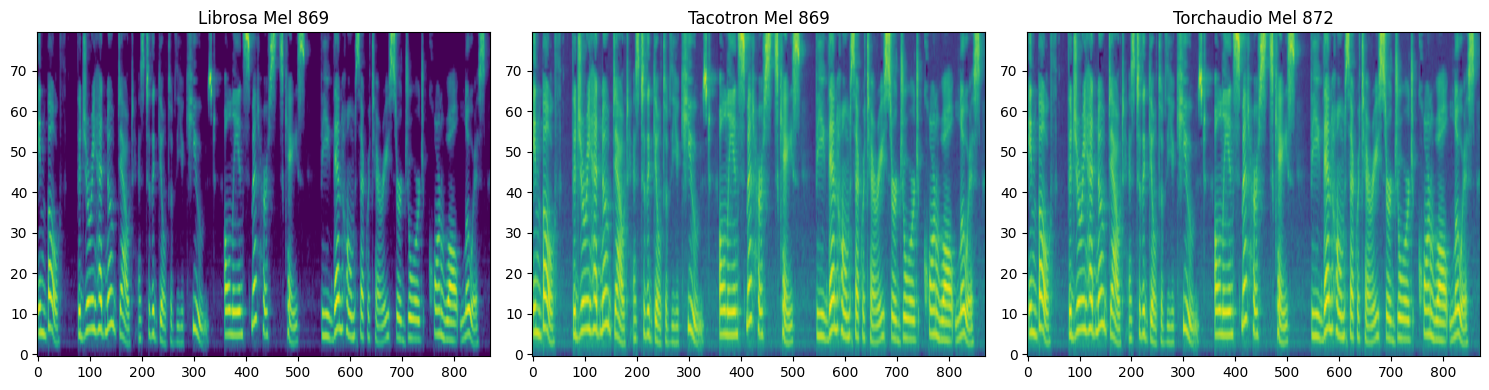

In [16]:
# Show both mels with matplotlib
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(librosa_mel, aspect="auto", origin="lower")
plt.title(f"Librosa Mel {librosa_mel.shape[1]}")
plt.subplot(1, 3, 2)
plt.imshow(tacotron_mel, aspect="auto", origin="lower")
plt.title(f"Tacotron Mel {tacotron_mel.shape[1]}")
plt.subplot(1, 3, 3)
plt.imshow(torchaudio_mel, aspect="auto", origin="lower")
plt.title(f"Torchaudio Mel {torchaudio_mel.shape[1]}")
plt.tight_layout()
plt.show()

In [6]:
energy

tensor([[ 0.4396,  3.3727, 12.7104, 24.8163, 27.1266, 27.6773, 27.5430, 27.2997,
         26.9837, 27.1097, 26.6213, 25.5172, 24.9727, 23.5346, 20.6628, 18.9265,
         19.5177, 20.8092, 20.8635, 20.5444, 18.3054, 17.1019, 17.8311, 16.2666,
         11.3462, 10.8147, 12.2398, 13.0523, 13.0801, 12.8925, 12.5859, 12.0410,
         10.4195,  7.7890, 14.0940, 21.3161, 14.0058,  7.6595,  3.1358,  1.4659,
          0.9131,  0.8528,  0.7438,  0.6381,  0.6076,  0.5820,  0.4535,  0.4393,
          0.4627,  0.3618,  0.3317,  0.3306,  0.3762,  0.4058,  0.3028,  0.2788,
          0.3443,  0.3425,  0.3142,  0.3256,  0.3448,  0.3062,  0.3021,  0.3375,
          0.3335,  0.3590,  2.1284,  8.9090, 16.0063, 24.0456, 54.8888, 66.0898,
         59.0221, 60.3552, 64.8257, 72.1908, 76.6896, 79.8322, 80.3643, 73.0078,
         66.4232, 60.5117, 54.6240, 39.0152, 27.3871, 28.1021, 30.9775, 41.6540,
         44.3947, 36.8037, 27.3676, 23.1404, 22.3899, 21.2955, 19.4575, 16.0952,
         11.6469,  7.8990,  

In [7]:
torch.norm(mel_output, dim=1)

NameError: name 'mel_output' is not defined

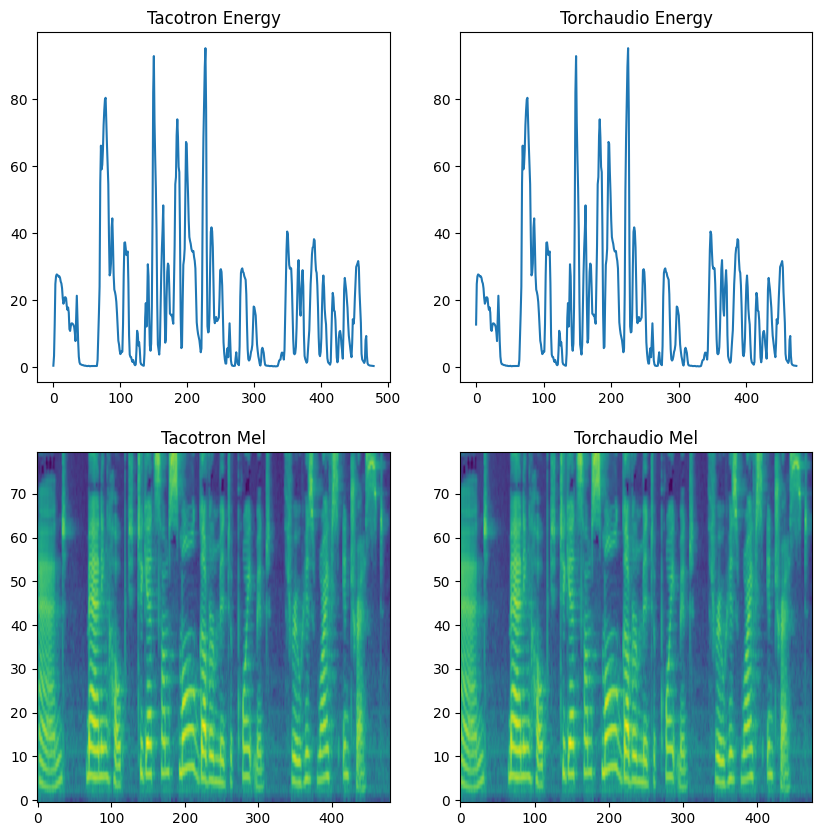

In [68]:
magnitudes, phases = tacotron_melspec.stft_fn.transform(audio_pt)
magnitudes = magnitudes.data
mel_output = torch.matmul(tacotron_melspec.mel_basis, magnitudes)
logmel_tacotron = tacotron_melspec.spectral_normalize(mel_output)
energy_tacotron = torch.norm(magnitudes, dim=1)

spectrogram = Spectrogram(
    n_fft=1024,
    win_length=1024,
    hop_length=256,
    center=True,
    power=1.0,
)
mel_scale = MelScale(
    n_mels=80,
    n_stft=1024 // 2 + 1,
    sample_rate=22050,
    f_min=0.0,
    f_max=8000.0,
    norm="slaney",
    mel_scale="slaney",
)
spectro = spectrogram(audio_pt)
energy_torchaudio = torch.norm(spectro, dim=1)
logmel_torchaudio = mel_scale(spectro)
logmel_torchaudio = torch.log(torch.clamp(logmel_torchaudio, min=1e-5))

# plot both energies with matplotlib
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.plot(energy_tacotron.squeeze().numpy())
plt.title("Tacotron Energy")
plt.subplot(2, 2, 2)
plt.plot(energy_torchaudio.squeeze().numpy())
plt.title("Torchaudio Energy")
plt.subplot(2, 2, 3)
plt.imshow(logmel_tacotron.squeeze().numpy(), aspect="auto", origin="lower")
plt.title("Tacotron Mel")
plt.subplot(2, 2, 4)
plt.imshow(logmel_torchaudio.squeeze().numpy(), aspect="auto", origin="lower")
plt.title("Torchaudio Mel")
plt.show()


In [59]:
energy_tacotron.size()

torch.Size([1, 479])